# S03.1 – Инструменты и форма данных для ML-эксперимента

Цель: научиться читать данные, понимать `X`/`y`, формы, типы, базовые проверки.

## Что вы освоите
- Понимать, чем отличаются признаки `X` и метки `y`
- Уметь делать первичный аудит данных (формы, типы, пропуски, базовые статистики)
- Освоить минимальный набор инструментов: NumPy, pandas, базовые графики Matplotlib
- Привычка к sanity-checks (маленькие проверки после каждого шага)

## Важные оговорки
- В этом ноутбуке мы почти не используем "модели". Это подготовка к честному эксперименту.
- Мы будем работать на табличных данных из scikit-learn, без скачивания внешних датасетов.

## Среда, воспроизводимость и стиль эксперимента

Перед кодом – несколько правил, которые будут повторяться во всех ноутбуках:

1) **Воспроизводимость**: фиксируем `random_state` / seed.  
2) **Разделение данных**: test‑часть – это *священная зона*. Мы смотрим на неё только в конце.  
3) **Всё, что “обучается” (`.fit`)** должно видеть только train‑данные (иначе легко получить утечки).  
4) **Sanity‑checks**: после каждого шага проверяем, что получился ожидаемый результат (формы, распределения, пересечения и т.д.).

In [1]:
# Импорты: минимальный, но достаточный набор
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Для красивых картинок (простая визуализация)
import matplotlib.pyplot as plt

# Фиксируем seed для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)

numpy: 2.0.2
pandas: 2.2.2


## Данные для демонстрации: `breast_cancer` (бинарная классификация)

Мы возьмём встроенный датасет из `sklearn.datasets`. Он удобен тем, что:
- не требует скачивания,
- уже приведён к табличному виду,
- задача – бинарная классификация (0/1).

Важно: сейчас вам **не нужно** понимать природу признаков. Наша цель – научиться *работать с формой данных*.

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print("X type:", type(X))
print("y type:", type(y))
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", data.target_names)

X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>
X shape: (569, 30)
y shape: (569,)
Target names: ['malignant' 'benign']


### Sanity-check 1: соответствие размеров

Частая ошибка новичков: `X` и `y` разной длины (например, забыли отфильтровать строки синхронно).
Проверим это явно.


In [3]:
assert len(X) == len(y), "Размеры X и y должны совпадать по числу объектов!"
print("OK: len(X) == len(y) =", len(X))

OK: len(X) == len(y) = 569


## Первичный аудит: типы, пропуски, описательные статистики

Почему это важно для безопасности/качества:
- пропуски и невалидные значения могут “сломать” пайплайн или дать неожиданную деградацию;
- странные распределения признаков могут указывать на ошибки сборки данных или на утечки.

Мы сделаем минимальный, но полезный аудит.


In [4]:
# Посмотрим первые строки
display(X.head())
display(y.head())

# Типы столбцов
print("dtypes (первые 10):")
display(X.dtypes.head(10))

# Пропуски
na = X.isna().sum()
print("Количество пропусков (если есть):")
display(na[na > 0].sort_values(ascending=False).head(10))

# Базовые статистики
display(X.describe().T.head(10))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,target
0,0
1,0
2,0
3,0
4,0


dtypes (первые 10):


,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


Количество пропусков (если есть):


,0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## Визуализация: распределения и выбросы (простыми средствами)

Мы не будем делать сложную аналитику. Просто посмотрим на 2-3 признака:
- гистограммы,
- boxplot (намёк на выбросы).

Цель: привыкнуть, что "посмотреть глазами" – нормальная часть инженерного процесса.

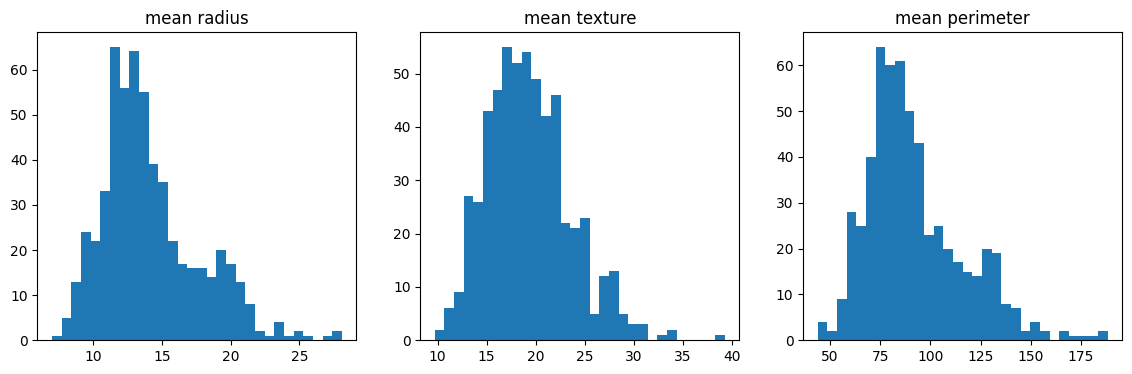

/tmp/ipykernel_311/94938017.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[c].values for c in cols], labels=cols)


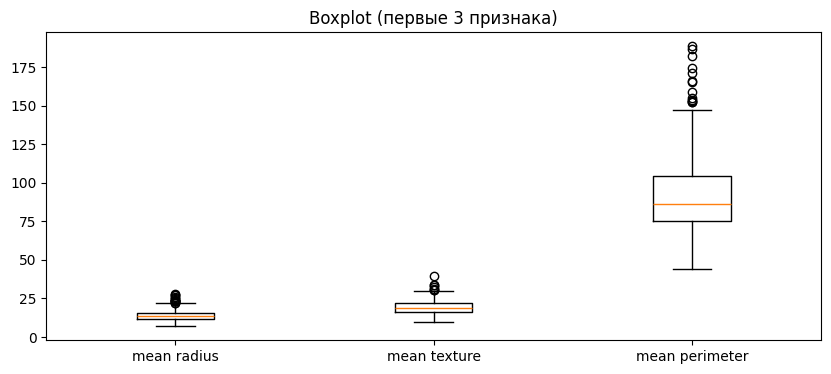

In [5]:
cols = list(X.columns[:3])
fig, axes = plt.subplots(1, len(cols), figsize=(14, 4))
for ax, c in zip(axes, cols):
    ax.hist(X[c].values, bins=30)
    ax.set_title(c)
plt.show()

# Boxplot для тех же признаков
plt.figure(figsize=(10, 4))
plt.boxplot([X[c].values for c in cols], labels=cols)
plt.title("Boxplot (первые 3 признака)")
plt.show()

## Мини-итог: что мы должны вынести из S03.1

1) Вы умеете получать `X` и `y`, проверять размеры, типы, пропуски.  
2) Вы умеете сделать минимум графиков, чтобы увидеть "неадекватность" данных глазами.  
3) Вы понимаете, что это часть **протокола эксперимента**, а не "разовая рутина".

В следующих ноутбуках мы добавим разбиение (split), baseline Dummy и метрики.